# mRMR Feature Selection — Top Features
Select 10 features from CYMO per-recording results using Minimum Redundancy Maximum Relevance.

---

In [1]:
CYMO_CSV = '../ParkCeleb/ann.cymo_parkceleb_per_recording.csv'       # CYMO output
META_CSV = './cymo_parkceleb_per_recording_metadata.csv'  # metadata
N_SELECT = 24

In [2]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from scipy import stats
import warnings; warnings.filterwarnings('ignore')
plt.rcParams.update({'figure.dpi': 130, 'font.size': 10, 'axes.titleweight': 'bold'})

In [3]:
# Load & merge
cymo = pd.read_csv(CYMO_CSV)
meta = pd.read_csv(META_CSV)
tid_col = 'TID' if 'TID' in cymo.columns else cymo.columns[0]
meta_tid = 'TID' if 'TID' in meta.columns else meta.columns[0]
feature_cols = [c for c in cymo.columns if c != tid_col]

df = cymo.merge(meta[[meta_tid, 'group', 'subject']].drop_duplicates(),
                left_on=tid_col, right_on=meta_tid, how='inner')
df['label'] = (df['group'] == 'PD').astype(int)

for col in feature_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Drop >50% missing and zero-variance
missing = df[feature_cols].isnull().sum() / len(df)
feature_cols = [c for c in feature_cols if missing[c] <= 0.5]
df[feature_cols] = df[feature_cols].fillna(df[feature_cols].median())
feature_cols = [c for c in feature_cols if df[c].var() > 1e-10]

print(f'{len(df)} recordings, {len(feature_cols)} features')
print(f'CN: {(df["label"]==0).sum()}  PD: {(df["label"]==1).sum()}')

143818 recordings, 344 features
CN: 80129  PD: 63689


In [4]:
# Compute relevance (|Spearman ρ| with label) and redundancy matrix
y = df['label'].values
relevance = {f: abs(stats.spearmanr(df[f].values, y)[0]) for f in feature_cols}

print('Computing pairwise correlations...')
corr_matrix = df[feature_cols].corr(method='spearman').abs()

#np.fill_diagonal(corr_matrix.values, 0)
corr_matrix = corr_matrix.mask(np.eye(len(corr_matrix), dtype=bool), 0)

print('Done.')

Computing pairwise correlations...
Done.


In [5]:
# mRMR selection
candidates = set(feature_cols)
selected = []
log = []

for step in range(N_SELECT):
    best_score, best_feat, best_rel, best_red = -np.inf, None, 0, 0
    for feat in candidates:
        rel = relevance.get(feat, 0)
        red = corr_matrix.loc[feat, [s for s, _, _, _ in selected]].mean() if selected else 0
        score = rel - red
        if score > best_score:
            best_score, best_feat, best_rel, best_red = score, feat, rel, red
    if best_feat is None:
        break
    selected.append((best_feat, best_rel, best_red, best_score))
    candidates.remove(best_feat)
    log.append({'step': step+1, 'feature': best_feat, 'relevance': best_rel,
                'redundancy': best_red, 'mrmr_score': best_score})

mrmr_df = pd.DataFrame(log)
mrmr_features = [row['feature'] for row in log]

print(f'\nSelected {len(mrmr_features)} features:\n')
print(f'{"#":<4s} {"Feature":<45s} {"Relevance":>10s} {"Redundancy":>11s} {"Score":>8s}')
print('─' * 82)
for _, r in mrmr_df.iterrows():
    print(f'{r["step"]:<4.0f} {r["feature"]:<45s} {r["relevance"]:>10.4f} {r["redundancy"]:>11.4f} {r["mrmr_score"]:>8.4f}')


Selected 24 features:

#    Feature                                        Relevance  Redundancy    Score
──────────────────────────────────────────────────────────────────────────────────
1    N2SLOb                                            0.2108      0.0000   0.2108
2    lwVAR                                             0.0284      0.0009   0.0276
3    TOPhea                                            0.0703      0.0460   0.0243
4    PRNposs1p                                         0.0472      0.0366   0.0106
5    NSAOb                                             0.0803      0.0600   0.0202
6    TOPent                                            0.0495      0.0330   0.0165
7    T50KCOCAw                                         0.0809      0.0602   0.0207
8    PRNposs2                                          0.0276      0.0173   0.0103
9    TOPpol                                            0.0607      0.0493   0.0114
10   NSLOb                                             0.1942  

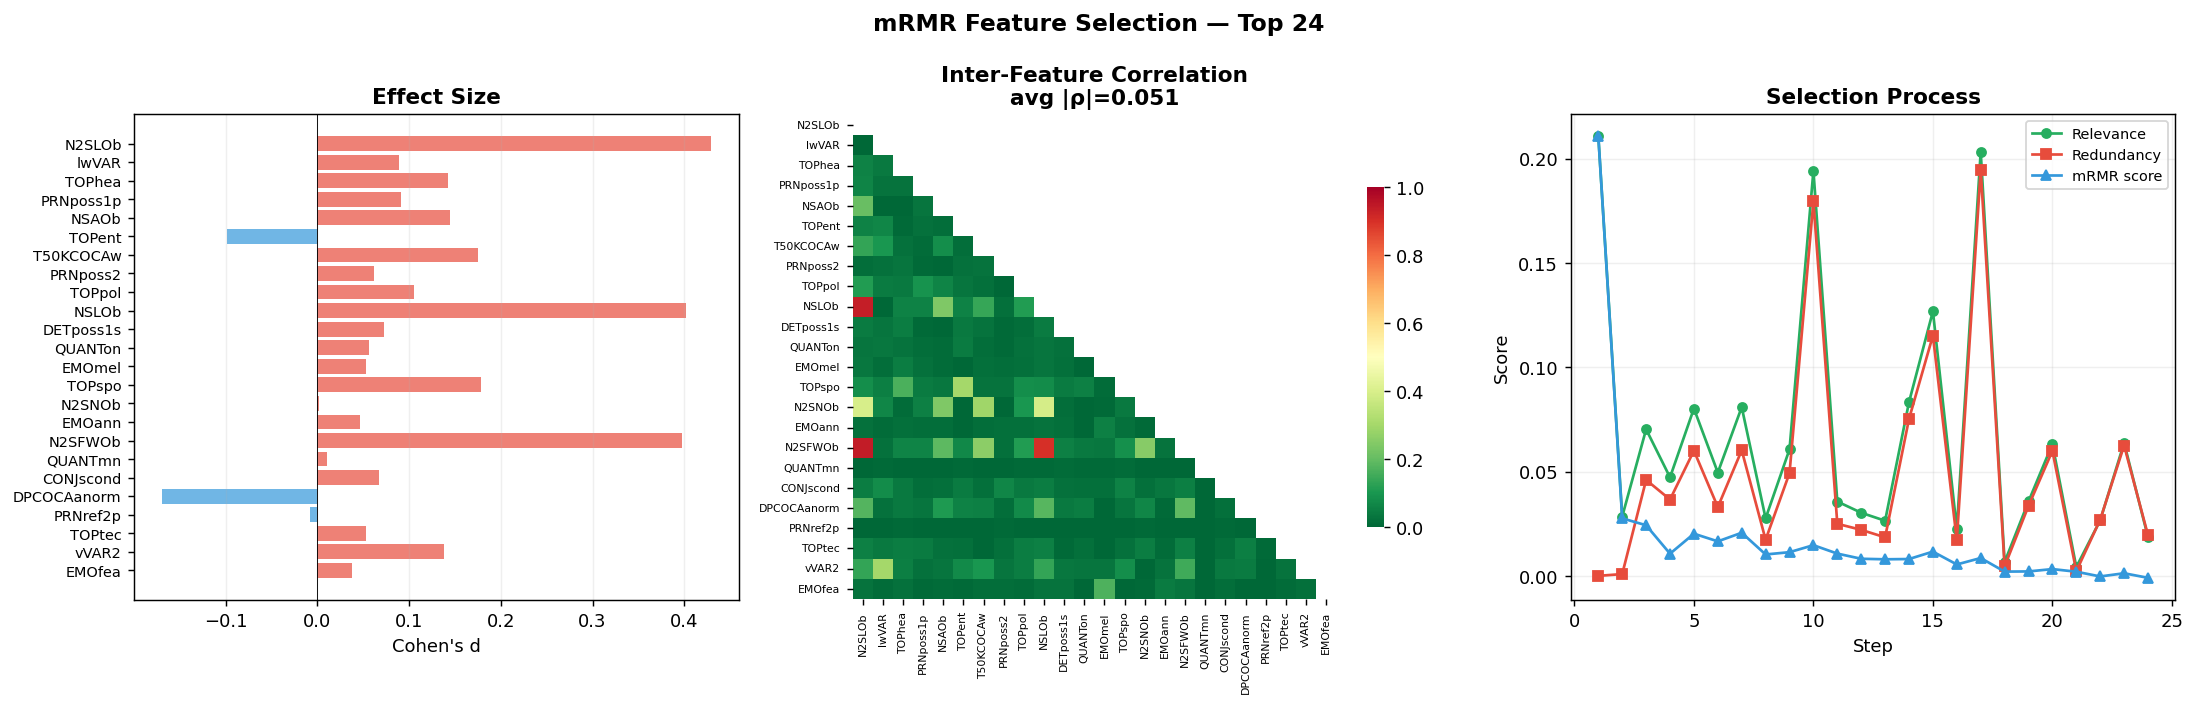

In [6]:
# Visualise
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# Effect size bars
ax = axes[0]
cn_df, pd_df = df[df['label']==0], df[df['label']==1]
d_vals = []
for f in mrmr_features:
    cn, pd_v = cn_df[f].dropna(), pd_df[f].dropna()
    pooled = np.sqrt(((len(cn)-1)*cn.var()+(len(pd_v)-1)*pd_v.var())/(len(cn)+len(pd_v)-2))
    d_vals.append((pd_v.mean()-cn.mean())/pooled if pooled > 0 else 0)
colors = ['#E74C3C' if d > 0 else '#3498DB' for d in d_vals]
ax.barh(range(N_SELECT), d_vals, color=colors, alpha=0.7)
ax.set_yticks(range(N_SELECT)); ax.set_yticklabels(mrmr_features, fontsize=8)
ax.set_xlabel("Cohen's d"); ax.set_title('Effect Size'); ax.axvline(0, color='k', lw=0.5)
ax.invert_yaxis(); ax.grid(axis='x', alpha=0.2)

# Correlation heatmap of selected features
ax = axes[1]
sel_corr = df[mrmr_features].corr(method='spearman').abs()
mask = np.triu(np.ones_like(sel_corr, dtype=bool))
sns.heatmap(sel_corr, mask=mask, cmap='RdYlGn_r', vmin=0, vmax=1, square=True,
            xticklabels=True, yticklabels=True, ax=ax, cbar_kws={'shrink': 0.7})

ax.tick_params(labelsize=6)
ax.set_title(f'Inter-Feature Correlation\navg |ρ|={sel_corr.values[np.triu_indices(N_SELECT,k=1)].mean():.3f}')

# mRMR score progression
ax = axes[2]
ax.plot(mrmr_df['step'], mrmr_df['relevance'], 'o-', color='#27AE60', label='Relevance', ms=5)
ax.plot(mrmr_df['step'], mrmr_df['redundancy'], 's-', color='#E74C3C', label='Redundancy', ms=5)
ax.plot(mrmr_df['step'], mrmr_df['mrmr_score'], '^-', color='#3498DB', label='mRMR score', ms=5)
ax.set_xlabel('Step'); ax.set_ylabel('Score'); ax.set_title('Selection Process')
ax.legend(fontsize=8); ax.grid(alpha=0.2)

plt.suptitle(f'mRMR Feature Selection — Top {N_SELECT}', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout(); plt.savefig('mrmr_top10_selection.png', dpi=150, bbox_inches='tight'); plt.show()

In [7]:
# Save
pd.DataFrame({'feature': mrmr_features}).to_csv('mrmr_top10_features.csv', index=False)
mrmr_df.to_csv('mrmr_top10_selection_log.csv', index=False)
print('Saved: mrmr_top10_features.csv')
print('Saved: mrmr_top10_selection_log.csv')

Saved: mrmr_top10_features.csv
Saved: mrmr_top10_selection_log.csv
